In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:

df = pd.read_csv("Msg_Intelligence_Datasetpro4.csv")

# Input features
X = df[
    [
        "message_length",
        "num_special_chars",
        "num_urls",
        "spam_keyword_score",
        "sender_activity_score",
        "hour_of_day",
        "day_of_week"
    ]
]

# Target var
y = df["spam_label"]

print("Input Features:")
print(X.columns)

print("\nTarget Variable:")
print(y.name)

print("\nX Shape:",X.shape)
print("y Shape:",y.shape)

Input Features:
Index(['message_length', 'num_special_chars', 'num_urls', 'spam_keyword_score',
       'sender_activity_score', 'hour_of_day', 'day_of_week'],
      dtype='object')

Target Variable:
spam_label

X Shape: (5200, 7)
y Shape: (5200,)


In [3]:
# q7 Basic Data Preprocessing + Scaling

# Missing values check
print("Missing values:")
print(X.isnull().sum())

# Missing values fill
imputer=SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

# Scaling
scaler=StandardScaler()
X=scaler.fit_transform(X)

print("\nData preprocessing completed")
print("Shape:",X.shape)

Missing values:
message_length             0
num_special_chars          0
num_urls                   0
spam_keyword_score         0
sender_activity_score    106
hour_of_day                0
day_of_week                0
dtype: int64

Data preprocessing completed
Shape: (5200, 7)


Training Data: (4160, 7)
Testing Data: (1040, 7)

Training Labels:
spam_label
0    3382
1     778
Name: count, dtype: int64

Testing Labels:
spam_label
0    845
1    195
Name: count, dtype: int64


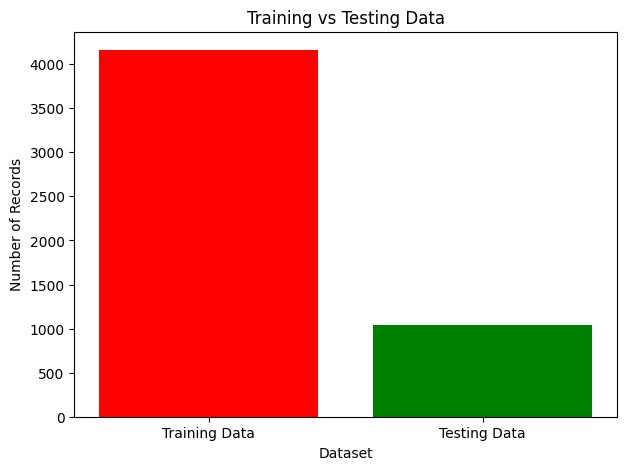

In [ ]:
# Q8 Training and Testing Data Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

print("\nTraining Labels:")
print(y_train.value_counts())

print("\nTesting Labels:")
print(y_test.value_counts())

# Chart - Training vs Testing Data
data = [
    len(X_train),
    len(X_test)
]

labels = [
    "Training Data",
    "Testing Data"
]

plt.figure(figsize=(7, 5))

plt.bar(labels, data,color=["red", "green"])

plt.title("Training vs Testing Data")
plt.xlabel("Dataset")
plt.ylabel("Number of Records")

plt.show()

In [5]:
# q9 Implement KNN classifier

# KNN model
knn=KNeighborsClassifier(n_neighbors=8)

# Train model
knn.fit(X_train,y_train)

# Prediction
y_pred=knn.predict(X_test)

# Accuracy
accuracy=accuracy_score(y_test,y_pred)

print("KNN Accuracy:",accuracy)

print("\nClassification Report:")
print(classification_report(y_test,y_pred))

KNN Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



In [6]:
# q10 Experiment with different values of K

k_values = [1, 3, 5, 7, 9, 11, 15, 20]

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train,y_train)

    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print("K=",k, "Accuracy=",accuracy)

K= 1 Accuracy= 1.0
K= 3 Accuracy= 1.0
K= 5 Accuracy= 1.0
K= 7 Accuracy= 1.0
K= 9 Accuracy= 1.0
K= 11 Accuracy= 0.9990384615384615
K= 15 Accuracy= 0.9990384615384615
K= 20 Accuracy= 0.9971153846153846


In [7]:
# q11 Analyze how distance metrics affect Predictions

metrics = ["euclidean","manhattan","minkowski"]

for metric in metrics:

    knn = KNeighborsClassifier(
        n_neighbors=5,
        metric=metric
    )

    knn.fit(X_train,y_train)

    y_pred=knn.predict(X_test)

    accuracy=accuracy_score(y_test,y_pred)

    print(metric, "Accuracy =",accuracy)

euclidean Accuracy = 1.0
manhattan Accuracy = 0.9971153846153846
minkowski Accuracy = 1.0


In [8]:
# q12 Identify Misclassified Msg
# Best/basic KNN
knn=KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)

y_pred=knn.predict(X_test)

# Misclassified
wrong = y_test != y_pred

print("Total Misclassified Messages:",wrong.sum())

# Original test data
test_data=df.loc[y_test.index].copy()

# Add predictions
test_data["Predicted_Label"] = y_pred

# Only wrong predictions
misclassified=test_data[wrong]

print("\nMisclassified Messages:")
print(
    misclassified[
        [
            "message_id",
            "message_text",
            "spam_label",
            "Predicted_Label"
        ]
    ].head(20)
)

Total Misclassified Messages: 0

Misclassified Messages:
Empty DataFrame
Columns: [message_id, message_text, spam_label, Predicted_Label]
Index: []


In [9]:
# q13 SVM — Linear Kernel

# Linear SVM
svm_linear=SVC(kernel="linear",random_state=42)

# Train
svm_linear.fit(X_train,y_train)

# Prediction
y_pred_svm=svm_linear.predict(X_test)

# Accuracy
accuracy=accuracy_score(y_test,y_pred_svm)

print("Linear SVM Accuracy:",accuracy)

print("\nClassification Report:")
print(classification_report(y_test,y_pred_svm))


# RBF SVM
svm_rbf=SVC(
    kernel="rbf",
    random_state=42
)

# Train
svm_rbf.fit(X_train, y_train)

# Prediction
y_pred_rbf=svm_rbf.predict(X_test)

# Accuracy
accuracy_rbf=accuracy_score(y_test,y_pred_rbf)

print("RBF SVM Accuracy:",accuracy_rbf)

print("\nClassification Report:")
print(classification_report(y_test,y_pred_rbf))

Linear SVM Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040

RBF SVM Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



In [10]:
# q14 Analyze margin Separation and support vectors
print("Number of Support Vectors:")
print(svm_linear.n_support_)

print("\nTotal Support Vectors:")
print(svm_linear.n_support_.sum())

Number of Support Vectors:
[14 10]

Total Support Vectors:
24


In [11]:
# q15 Compare SVM Performance with KNN

# KNN
knn=KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)

knn_pred=knn.predict(X_test)

knn_accuracy=accuracy_score(y_test,knn_pred)


# Linear SVM
svm_linear=SVC(kernel="linear",random_state=42)

svm_linear.fit(X_train, y_train)

svm_pred=svm_linear.predict(X_test)

svm_accuracy=accuracy_score(y_test,svm_pred)


# RBF SVM
svm_rbf=SVC(kernel="rbf",random_state=42)

svm_rbf.fit(X_train,y_train)

rbf_pred=svm_rbf.predict(X_test)

rbf_accuracy=accuracy_score(y_test,rbf_pred)


print("KNN Accuracy:", knn_accuracy)
print("Linear SVM Accuracy:", svm_accuracy)
print("RBF SVM Accuracy:", rbf_accuracy)

KNN Accuracy: 1.0
Linear SVM Accuracy: 1.0
RBF SVM Accuracy: 1.0


In [12]:
# q16 Implement Naive Bayes Classifier
# Naive Bayes model
nb=GaussianNB()

# Train
nb.fit(X_train,y_train)

# Prediction
y_pred_nb=nb.predict(X_test)

# Accuracy
nb_accuracy=accuracy_score(y_test,y_pred_nb)

print("Naive Bayes Accuracy:",nb_accuracy)

print("\nClassification Report:")
print(classification_report(y_test,y_pred_nb))

Naive Bayes Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



In [13]:
# q17 Manually compute conditional Probability
# Create a simple condition
url_spam=df[df["num_urls"] >= 1]

spam_count=len(
    url_spam[url_spam["spam_label"] == 1]
)

total_url_messages=len(url_spam)

conditional_probability = spam_count / total_url_messages

print("P(Spam | Number of URLs >= 1) =",conditional_probability)

P(Spam | Number of URLs >= 1) = 0.6694599627560521


In [14]:
# q18 Demonstrate how bayes Theorem Calculates Probability
# Total messages
total=len(df)

# Spam messages
spam=df[df["spam_label"] == 1]

# Messages having at least 1 URL
url_messages=df[df["num_urls"]>= 1]

# URL messages that are spam
url_spam=url_messages[
    url_messages["spam_label"] == 1
]


# P(Spam)
P_spam=len(spam) / total

# P(URL | Spam)
P_url_given_spam=len(url_spam) / len(spam)

# P(URL)
P_url=len(url_messages) / total


# Bayes Theorem
P_spam_given_url=(
    P_url_given_spam * P_spam
) / P_url


print("P(Spam)=", P_spam)

print("P(URL | Spam) =",
      P_url_given_spam)

print("P(URL) =",
      P_url)

print("\nP(Spam | URL) =",
      P_spam_given_url)

P(Spam)= 0.18711538461538463
P(URL | Spam) = 0.7389516957862282
P(URL) = 0.20653846153846153

P(Spam | URL) = 0.6694599627560522


In [15]:
# q19 Compare theoretical probability with Model Prediction
# Probability prediction
probabilities=nb.predict_proba(X_test)

# Spam probability
spam_probability=probabilities[:,1]

# First 10 predictions
for i in range(10):

    print(
        "Actual:",
        y_test.iloc[i],
        "| Predicted:",
        y_pred_nb[i],
        "| Spam Probability:",
        round(spam_probability[i],4)
    )

Actual: 0 | Predicted: 0 | Spam Probability: 0.0
Actual: 1 | Predicted: 1 | Spam Probability: 1.0
Actual: 0 | Predicted: 0 | Spam Probability: 0.0
Actual: 0 | Predicted: 0 | Spam Probability: 0.0
Actual: 0 | Predicted: 0 | Spam Probability: 0.0
Actual: 0 | Predicted: 0 | Spam Probability: 0.0
Actual: 0 | Predicted: 0 | Spam Probability: 0.0
Actual: 0 | Predicted: 0 | Spam Probability: 0.0
Actual: 0 | Predicted: 0 | Spam Probability: 0.0
Actual: 0 | Predicted: 0 | Spam Probability: 0.0


In [16]:
# q20 Evaluate all models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# KNN Prediction
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)


# Linear SVM Prediction
svm_linear = SVC(kernel="linear", random_state=42)
svm_linear.fit(X_train, y_train)
svm_pred = svm_linear.predict(X_test)


# Naive Bayes Prediction
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)


# Function to calculate metrics
def calculate_metrics(y_test, prediction):
    
    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall = recall_score(y_test, prediction)
    f1 = f1_score(y_test, prediction)
    
    return accuracy, precision, recall, f1


# Calculate metrics
knn_metrics = calculate_metrics(y_test, knn_pred)
svm_metrics = calculate_metrics(y_test, svm_pred)
nb_metrics = calculate_metrics(y_test, nb_pred)


print("KNN")
print("Accuracy :", knn_metrics[0])
print("Precision:", knn_metrics[1])
print("Recall   :", knn_metrics[2])
print("F1 Score :", knn_metrics[3])


print("\nSVM")
print("Accuracy :", svm_metrics[0])
print("Precision:", svm_metrics[1])
print("Recall   :", svm_metrics[2])
print("F1 Score :", svm_metrics[3])


print("\nNaive Bayes")
print("Accuracy :", nb_metrics[0])
print("Precision:", nb_metrics[1])
print("Recall   :", nb_metrics[2])
print("F1 Score :", nb_metrics[3])


KNN
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

SVM
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Naive Bayes
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [17]:
# q21 KNN vs SVM vs Naive Bayes

comparison=pd.DataFrame({
    "Model":[
        "KNN",
        "SVM",
        "Naive Bayes"
    ],
    
    "Accuracy":[
        knn_metrics[0],
        svm_metrics[0],
        nb_metrics[0]
    ],
    
    "Precision":[
        knn_metrics[1],
        svm_metrics[1],
        nb_metrics[1]
    ],
    
    "Recall":[
        knn_metrics[2],
        svm_metrics[2],
        nb_metrics[2]
    ],
    
    "F1 Score":[
        knn_metrics[3],
        svm_metrics[3],
        nb_metrics[3]
    ]
})

print(comparison.round(4))

         Model  Accuracy  Precision  Recall  F1 Score
0          KNN       1.0        1.0     1.0       1.0
1          SVM       1.0        1.0     1.0       1.0
2  Naive Bayes       1.0        1.0     1.0       1.0


In [18]:
# q22 Best Model for High Precision & High Recall
# Best Precision
models={
    "KNN": knn_metrics,
    "SVM": svm_metrics,
    "Naive Bayes": nb_metrics
}

best_precision_model=max(
    models,
    key=lambda x: models[x][1]
)

print(
    "Best Model for High Precision:",
    best_precision_model
)

print(
    "Precision:",
    models[best_precision_model][1]
)

# q22 Best Recall
best_recall_model=max(
    models,
    key=lambda x: models[x][2]
)

print(
    "Best Model for High Recall:",
    best_recall_model
)

print(
    "Recall:",
    models[best_recall_model][2]
)

Best Model for High Precision: KNN
Precision: 1.0
Best Model for High Recall: KNN
Recall: 1.0


In [19]:
# q23 final report

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


#Calculate Model Performance
models = {
    "KNN":knn_pred,
    "SVM":svm_pred,
    "Naive Bayes":nb_pred
}

results = []

for model_name,prediction in models.items():

    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall = recall_score(y_test, prediction)
    f1 = f1_score(y_test, prediction)

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])


report = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)


print("=" * 60)
print("FINAL MODEL PERFORMANCE REPORT")
print("=" * 60)

print(report.round(4))



#  Find Best Model

best_accuracy=report.loc[
    report["Accuracy"].idxmax()
]

best_precision=report.loc[
    report["Precision"].idxmax()
]

best_recall=report.loc[
    report["Recall"].idxmax()
]

best_f1=report.loc[
    report["F1 Score"].idxmax()
]


print("\n" + "=" * 60)
print("BEST MODELS")
print("=" * 60)

print(
    "Best Accuracy :",
    best_accuracy["Model"],
    "->",
    round(best_accuracy["Accuracy"],4)
)

print(
    "Best Precision:",
    best_precision["Model"],
    "->",
    round(best_precision["Precision"],4)
)

print(
    "Best Recall   :",
    best_recall["Model"],
    "->",
    round(best_recall["Recall"],4)
)

print(
    "Best F1 Score :",
    best_f1["Model"],
    "->",
    round(best_f1["F1 Score"],4)
)



#  Strengths and Weaknesses

print("\n" + "=" * 60)
print("STRENGTHS AND WEAKNESSES")
print("=" * 60)

print("\nKNN")
print("Strength : Simple and easy to understand")
print("Weakness : Sensitive to scaling and choice of K")

print("\nSVM")
print("Strength : Strong classification and good decision boundary")
print("Weakness : Parameter selection can be difficult")

print("\nNaive Bayes")
print("Strength : Fast and provides probability estimates")
print("Weakness : Assumes features are independent")


# Naive Bayes Probability Assumption

print("\n" + "=" * 60)
print("NAIVE BAYES PROBABILITY ASSUMPTION")
print("=" * 60)

print(
    "Naive Bayes assumes that features are conditionally"
)
print(
    "independent given the target class"
)

print(
    "If features are highly related, this assumption may"
)
print(
    "affect model performance"
)


# 
#  Interpretability vs Performance


print("\n" + "=" * 60)
print("INTERPRETABILITY VS PERFORMANCE")
print("=" * 60)

print("KNN        : Easy to understand")
print("Naive Bayes: Easy probability interpretation")
print("SVM        : Strong performance but less interpretable")


#  Business Recommendation

print("\n" + "=" * 60)
print("BUSINESS RECOMMENDATION")
print("=" * 60)

print(
    "For Spam Message Detection, both Precision and Recall"
)
print(
    "are important"
)

print(
    "High Recall helps detect more actual Spam messages"
)

print(
    "High Precision helps reduce genuine messages being"
)
print(
    "incorrectly classified as Spam"
)

print(
    "\nRecommended Model based on F1 Score:",
    best_f1["Model"]
)

print(
    "This model provides the best balance between Precision"
)
print(
    "and Recall among the tested models"
)



#  Final Conclusion

print("\n" + "=" * 60)
print("FINAL CONCLUSION")
print("=" * 60)

print(
    "KNN, SVM and Naive Bayes were successfully evaluated"
)

print(
    "The final model should be selected using Precision,"
)

print(
    "Recall and F1 Score along with Accuracy"
)

print(
    "For real-world Spam Detection, a model with high Recall"
)

print(
    "and good Precision is recommended"
)

FINAL MODEL PERFORMANCE REPORT
         Model  Accuracy  Precision  Recall  F1 Score
0          KNN       1.0        1.0     1.0       1.0
1          SVM       1.0        1.0     1.0       1.0
2  Naive Bayes       1.0        1.0     1.0       1.0

BEST MODELS
Best Accuracy : KNN -> 1.0
Best Precision: KNN -> 1.0
Best Recall   : KNN -> 1.0
Best F1 Score : KNN -> 1.0

STRENGTHS AND WEAKNESSES

KNN
Strength : Simple and easy to understand
Weakness : Sensitive to scaling and choice of K

SVM
Strength : Strong classification and good decision boundary
Weakness : Parameter selection can be difficult

Naive Bayes
Strength : Fast and provides probability estimates
Weakness : Assumes features are independent

NAIVE BAYES PROBABILITY ASSUMPTION
Naive Bayes assumes that features are conditionally
independent given the target class
If features are highly related, this assumption may
affect model performance

INTERPRETABILITY VS PERFORMANCE
KNN        : Easy to understand
Naive Bayes: Easy probabil

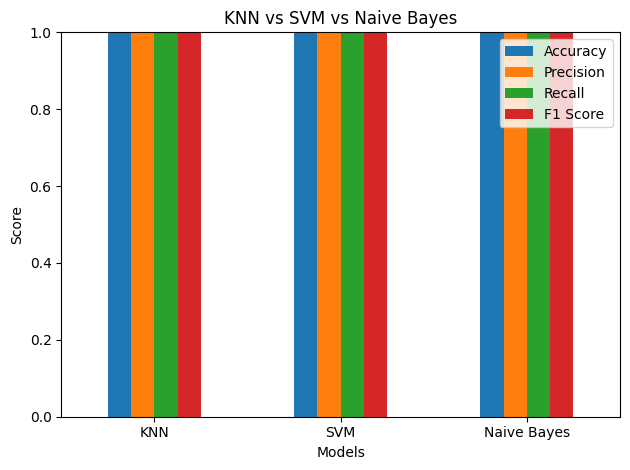

In [20]:
# q24 
# Model Comparison Plot

comparison.plot(
    x="Model",
    y=["Accuracy","Precision","Recall","F1 Score"],
    kind="bar"
)

plt.title("KNN vs SVM vs Naive Bayes")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

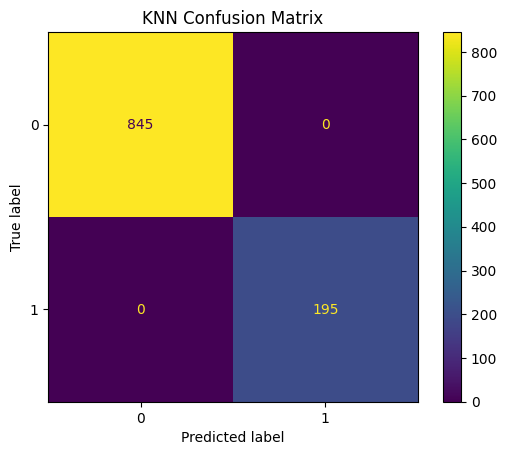

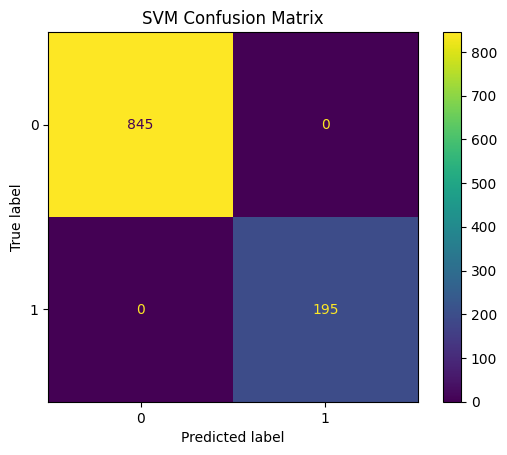

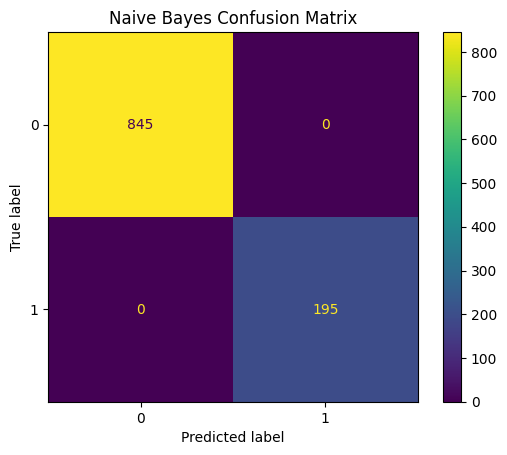

In [21]:

# KNN Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred
)

plt.title("KNN Confusion Matrix")
plt.show()


# SVM Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_pred
)

plt.title("SVM Confusion Matrix")
plt.show()


# Naive Bayes Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_pred
)

plt.title("Naive Bayes Confusion Matrix")
plt.show()